In [102]:
%pip install gymnasium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
%pip uninstall gym gymnasium shimmy -y
%pip install gymnasium

Found existing installation: gymnasium 1.3.0
Uninstalling gymnasium-1.3.0:
  Successfully uninstalled gymnasium-1.3.0
Note: you may need to restart the kernel to use updated packages.


  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [105]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Markov decision process

In [106]:
import sys, os
import numpy as np 
import gymnasium as gym
import matplotlib as plt
from mdp import MDP

In [107]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1.0}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s0': 0.95, 's2': 0.05}
    },
    's2': {
            'a0': {'s0': 0.4, 's2': 0.6},
            'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

In [108]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


In [109]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


## Optional: Visualizing MDPs

In [110]:
from mdp import MDP
import mdp as mdp_module
print("Graphviz available:", mdp_module.has_graphviz)

Graphviz available: True


In [111]:
from mdp import has_graphviz

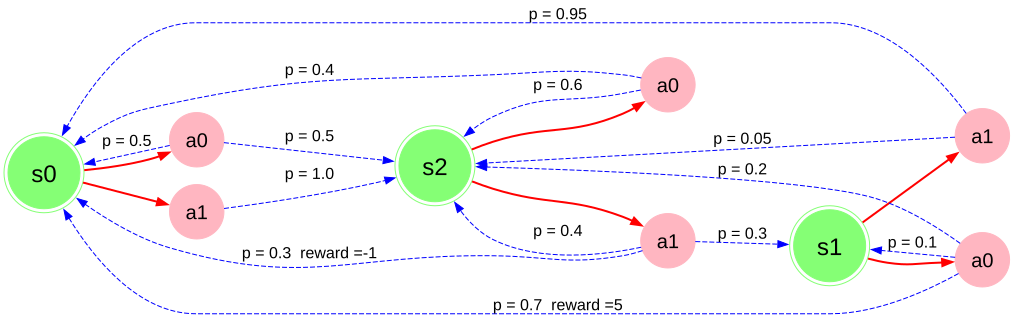

In [112]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

## Value Iteration

In [113]:
def get_action_value(mdp, state_values, state, action, gamma):
    Q = 0
    for next_state, prob in mdp.get_next_states(state, action).items():
        reward = mdp.get_reward(state, action, next_state)
        Q += prob * (reward + gamma * state_values[next_state])
    return Q

In [114]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

In [115]:
def get_new_state_value(mdp, state_values, state, gamma):
    if mdp.is_terminal(state):
        return 0
    action_values = [
        get_action_value(mdp, state_values, state, action, gamma)
        for action in mdp.get_possible_actions(state)
    ]
    return max(action_values)

In [116]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

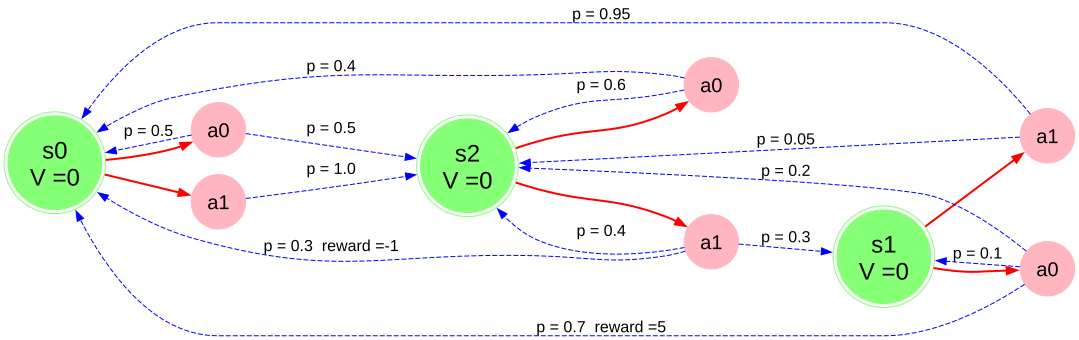

iter    0 | diff: 3.50000 | V(s0) = 0.000 V(s1) = 0.000 V(s2) = 0.000
iter    1 | diff: 0.64500 | V(s0) = 0.000 V(s1) = 3.500 V(s2) = 0.000
iter    2 | diff: 0.58050 | V(s0) = 0.000 V(s1) = 3.815 V(s2) = 0.645
iter    3 | diff: 0.43582 | V(s0) = 0.581 V(s1) = 3.959 V(s2) = 0.962
iter    4 | diff: 0.30634 | V(s0) = 0.866 V(s1) = 4.395 V(s2) = 1.272
iter    5 | diff: 0.27571 | V(s0) = 1.145 V(s1) = 4.670 V(s2) = 1.579
iter    6 | diff: 0.24347 | V(s0) = 1.421 V(s1) = 4.926 V(s2) = 1.838
iter    7 | diff: 0.21419 | V(s0) = 1.655 V(s1) = 5.169 V(s2) = 2.075
iter    8 | diff: 0.19277 | V(s0) = 1.868 V(s1) = 5.381 V(s2) = 2.290
iter    9 | diff: 0.17327 | V(s0) = 2.061 V(s1) = 5.573 V(s2) = 2.481
iter   10 | diff: 0.15569 | V(s0) = 2.233 V(s1) = 5.746 V(s2) = 2.654
iter   11 | diff: 0.14012 | V(s0) = 2.389 V(s1) = 5.902 V(s2) = 2.810
iter   12 | diff: 0.12610 | V(s0) = 2.529 V(s1) = 6.042 V(s2) = 2.950
iter   13 | diff: 0.11348 | V(s0) = 2.655 V(s1) = 6.168 V(s2) = 3.076
iter   14 | diff: 0.

In [117]:
gamma = 0.9
num_iter = 100
min_difference = 0.001

state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):
    new_state_values = {
        s : get_new_state_value(mdp, state_values, s, gamma)
        for s in mdp.get_all_states()
    }
    assert isinstance(new_state_values, dict)
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i | diff: %6.5f | "% (i, diff), end="")
    print(' '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

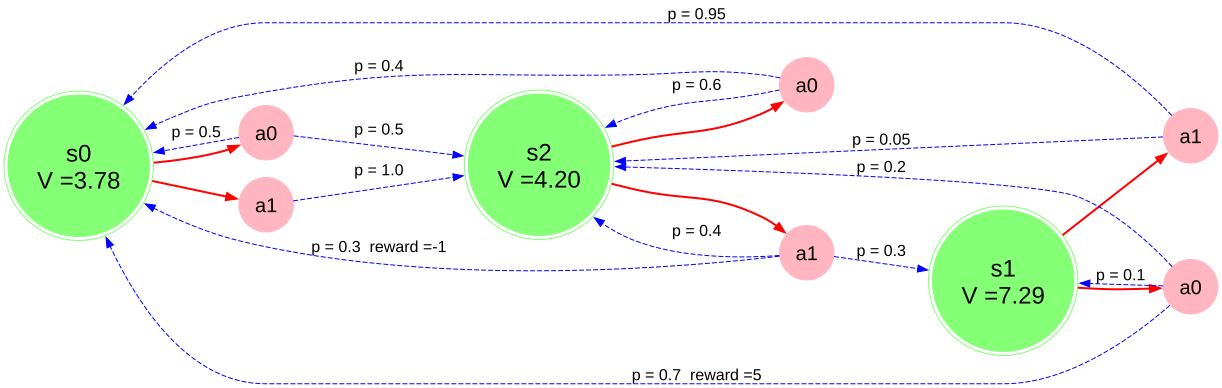

In [118]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [119]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


In [120]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    if mdp.is_terminal(state):
        return None
    actions = mdp.get_possible_actions(state)

    best_action = max(
        actions,
        key = lambda action: get_action_value(mdp, state_values, state, action, gamma)
    )

    return best_action

In [121]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

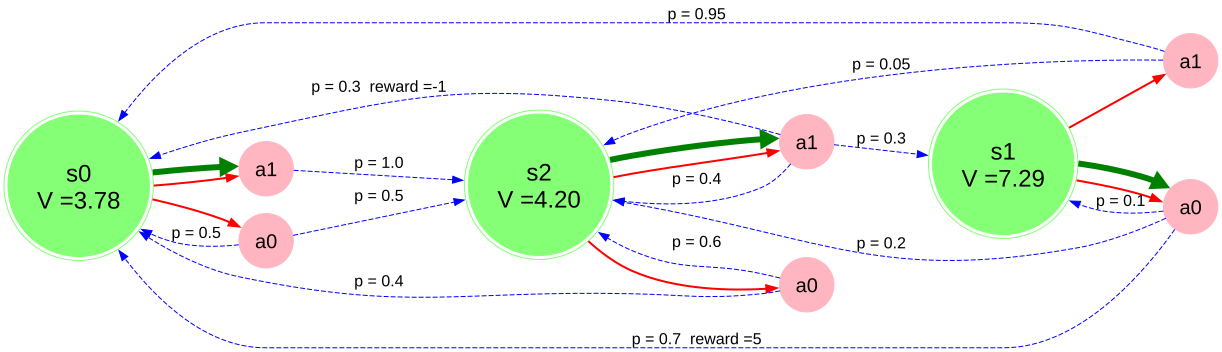

In [122]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [123]:
s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4453


## Frozen lake

In [124]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [125]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    state_values = state_values or {s : 0 for s in mdp.get_all_states()}
    for i in range(num_iter):
        new_state_values = {
            s: get_new_state_value(mdp, state_values, s, gamma)
            for s in mdp.get_all_states()
        }

        assert isinstance(new_state_values, dict)

        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [126]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [127]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



## Let's visualize!

In [128]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


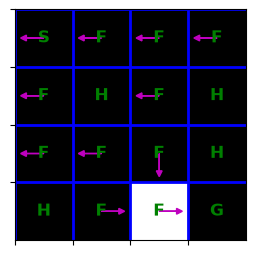

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


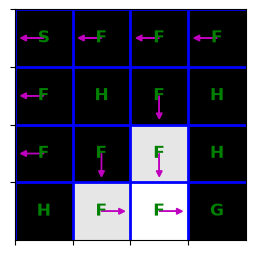

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


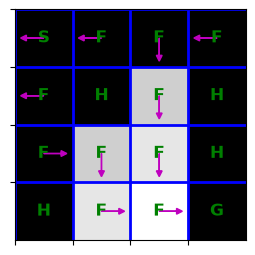

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


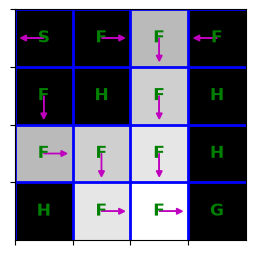

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


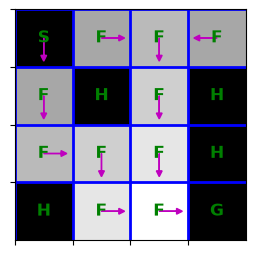

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


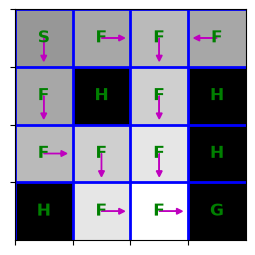

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


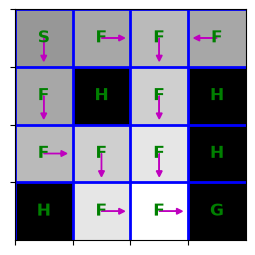

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


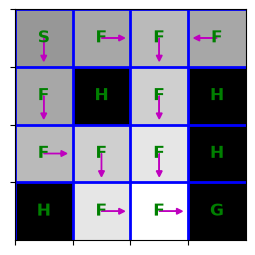

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


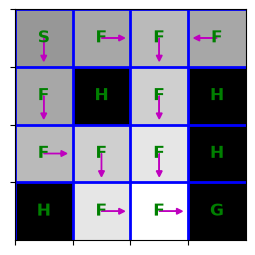

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


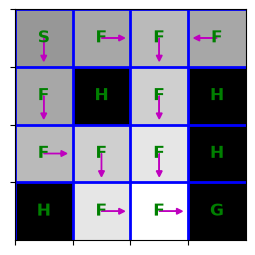

In [129]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


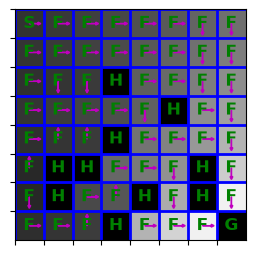

In [130]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)

**Massive tests**

In [131]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [ ]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.885
Well done!


In [135]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [134]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

## HW Part 1: Value iteration convergence

In [143]:
transition_probs = {
    's0' : {
        'a0' : {'s0' : 1},
        'a1' : {'s1' : 1},
    },
    's1' : {
        'a0' : {'s1' : 1},
        'a1' : {'s1' : 1},
    },
}
rewards = {
    's0' : {
        'a0' : {'s0' : 1},
    },
    's1' : {
        'a0' : {'s1' : 1.055},
        'a1' : {'s1' : 1.055},
    },
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

In [144]:
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
iter    0   |   diff: 1.05500   |   V(start): 1.000 
N actions changed = 0 

after iteration 1
iter    0   |   diff: 0.94950   |   V(start): 1.900 
N actions changed = 0 

after iteration 2
iter    0   |   diff: 0.85455   |   V(start): 2.710 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 0.76910   |   V(start): 3.439 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 0.69219   |   V(start): 4.095 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 0.62297   |   V(start): 4.686 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 0.56067   |   V(start): 5.217 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 0.50460   |   V(start): 5.695 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 0.45414   |   V(start): 6.126 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 0.40873   |   V(start): 6.513 
N actions changed = 0 

after iteration 10
iter    0   |   diff: 0.36786  

## HW Part 2: Policy iteration

In [145]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

In [148]:
def compute_vpi(mdp, policy, gamma):
    states = mdp.get_all_states()
    n = len(states)
    state_index = {s : i for i, s in enumerate(states)}
    A = np.eye(n)
    b = np.zeros(n)

    for s in states:
        i = state_index[s]
        if mdp.is_terminal(s):
            continue
        action = policy[s]
        for next_state, prob in mdp.get_next_states(s, action).items():
            j = state_index[next_state]
            reward = mdp.get_reward(s, action, next_state)
            A[i, j] -= gamma * prob
            b[i] += prob * reward

    V = np.linalg.solve(A, b)

    return {s: V[state_index[s]] for s in states}

In [149]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(2.8399699474079663), 's1': np.float64(6.498873027798649), 's2': np.float64(3.4710743801652932)}


In [150]:
def compute_new_policy(mdp, vpi, gamma):
    return {
        s: get_optimal_action(mdp, vpi, s, gamma)
        for s in mdp.get_all_states()
    }

In [151]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a1', 's1': 'a0', 's2': 'a0'}


In [ ]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    states = mdp.get_all_states()

    if policy is None:
        policy = {}
        for s in states:
            if mdp.is_terminal(s):
                policy[s] = None
            else:
                policy[s] = random.choice(mdp.get_possible_actions(s))

    state_values = {s: 0 for s in states}

    for i in range(num_iter):
        new_state_values = compute_vpi(mdp, policy, gamma)
        new_policy = compute_new_policy(mdp, new_state_values, gamma)

        diff = max(abs(new_state_values[s] - state_values[s]) for s in states)

        state_values = new_state_values
        policy = new_policy

        if diff < min_difference:
            break

    return state_values, policy

In [154]:
import time

def compare_pi_vi(mdp, gamma=0.9, name=""):
    print(f"===== {name} =====")

    # Value Iteration
    t0 = time.time()
    vi_values = value_iteration(mdp, gamma=gamma)
    vi_time = time.time() - t0
    vi_policy = {
        s: get_optimal_action(mdp, vi_values, s, gamma)
        for s in mdp.get_all_states()
    }

    # Policy Iteration
    t0 = time.time()
    pi_values, pi_policy = policy_iteration(mdp, gamma=gamma)
    pi_time = time.time() - t0

    print(f"VI time: {vi_time:.4f}s")
    print(f"PI time: {pi_time:.4f}s")

    # So sánh giá trị hội tụ có khớp nhau không
    diff = max(abs(vi_values[s] - pi_values[s]) for s in mdp.get_all_states())
    print(f"Max |V_VI - V_PI| = {diff:.6f}")

    # So sánh chính sách có giống nhau không
    same_policy = all(vi_policy[s] == pi_policy[s] for s in mdp.get_all_states())
    print(f"Policies match: {same_policy}")
    print()


# 1. MDP từ bonus 1 (bài slow-convergence)
compare_pi_vi(mdp, gamma=0.95, name="Bonus 1 MDP (slow VI)")

# 2. FrozenLake nhỏ
from mdp import FrozenLakeEnv
mdp_small = FrozenLakeEnv(map_name='4x4', slip_chance=0.25)
compare_pi_vi(mdp_small, gamma=0.9, name="FrozenLake 4x4")

# 3. FrozenLake lớn
mdp_large = FrozenLakeEnv(map_name='8x8')

===== Bonus 1 MDP (slow VI) =====
iter    0   |   diff: 3.50000   |   V(start): 0.000 
iter    1   |   diff: 1.99500   |   V(start): 0.000 
iter    2   |   diff: 1.89525   |   V(start): 1.895 
iter    3   |   diff: 1.33536   |   V(start): 2.075 
iter    4   |   diff: 0.90655   |   V(start): 2.982 
iter    5   |   diff: 0.80112   |   V(start): 3.770 
iter    6   |   diff: 0.75612   |   V(start): 4.329 
iter    7   |   diff: 0.71831   |   V(start): 5.047 
iter    8   |   diff: 0.65053   |   V(start): 5.635 
iter    9   |   diff: 0.59399   |   V(start): 6.210 
iter   10   |   diff: 0.56429   |   V(start): 6.774 
iter   11   |   diff: 0.53038   |   V(start): 7.289 
iter   12   |   diff: 0.50107   |   V(start): 7.790 
iter   13   |   diff: 0.47465   |   V(start): 8.263 
iter   14   |   diff: 0.45031   |   V(start): 8.711 
iter   15   |   diff: 0.42779   |   V(start): 9.138 
iter   16   |   diff: 0.40594   |   V(start): 9.543 
iter   17   |   diff: 0.38526   |   V(start): 9.928 
iter   18   